In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
# Libraries need for model training
#DATE : 28/04/2026
#-------------------------
'''RealEstatePricePredict'''
#-------------------------
df = pd.DataFrame(dataset)
#print(df)

#----------------------------------------------------------------------------
''' we need to clean the data as it contains "$","sq.ft", "K/sq.ft" char!'''
#----------------------------------------------------------------------------
df["size"] = df["size"].str.replace("sq.ft"," ").astype(int) # Assumed size to be fixed integer
df["price"] = df["price"].str.replace("₹"," ").str.replace("K/ sq.ft"," ").astype(float) * 1000 # Multiplying by 1000 changes the price into price of hundreds i.e. 1.5 -> 1500 

"""-------------------------------------------------------
#Now we will difine the Independed and Dependent variable
----------------------------------------------------------
since their are labeled varialbles we need to convert it into 1s and 0s"""
df_encoded = pd.get_dummies(df, columns=['place'], drop_first =True) # This is the encoded dataframe with places replaced with 1 and 0, this will become our main df

X = df_encoded.drop(["price"], axis = 1) # drops columns price from the data set as those were not independent variables
Y = df_encoded["price"] # target / dependent variable, we'll predict this !

#------------------------------------------------
"""Now spilting the data for training and testing"""
#---------------------------------------------------
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size= 0.2,random_state = 42)

#----------------------------------
'''creating model and training it!'''
#----------------------------------
Model = LinearRegression()
Model.fit(x_train,y_train)

#Now predicting the result/output
y_pred = Model.predict(x_test)
# print("Predicted value : ",y_pred)

#Getting Coefficient and Intercept
print("Coefficients:", Model.coef_)
print("Intercept:", Model.intercept_)

#----------------------
'''Data Visualization:'''
#----------------------
def ShowData(df):
    chart = sns.lmplot(data=df,x="size",y="price",hue="place",height=7,aspect=1.5,scatter_kws={"s": 50, "alpha": 0.6},line_kws={"linewidth": 1})
    
    plt.title('Real Estate Trend: Size vs Price with City Trendlines')
    plt.xlabel('Size (sq.ft)')
    plt.ylabel('Rate (₹K / sq.ft)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# R² score for linear Regression(checking the efficiency of the model)
r2_sc_linear = r2_score(y_test, y_pred)
print("R² score (Linear Regression): ", r2_sc_linear) # if its ~~ 0.9 then the model will do good prediction 

'''
#Now checking the difference btw the predicted value and the actual value for the same input of data
#It can be done through mean_absolute-error function from sklear lib
'''
MAE_score = mean_absolute_error(y_test,y_pred) / 1000
print(f"Mean Absolute Error : ₹{MAE_score:.2f}K /sq.ft")

#custom input function for prediction
def custom_data(size,place):
    corrs_colm = x_train.columns # input is in the dataframe foramt we created a blueprint of the input cols
    cs_dt = pd.DataFrame(0, index=[0], columns = corrs_colm)  #single row df with corresponding colms names
    
    cs_dt["size"] =  size
    col_name = "place_"+place
    if col_name in cs_dt.columns:
        cs_dt[col_name] = 1

    return cs_dt
    
def RealEstatePricePredict(size,place):
    c1 = (custom_data(size,place)) 
    predict_model = Model.predict(c1)
    price_rate = predict_model[0] 
    totle_price_plot = size * price_rate
    print(f"The Price for the Plot size of {inp_size} sq.ft in {inp_place} will be ₹{totle_price_plot:.2f} with plot_rate of ₹{price_rate:.2f}/sq.ft")


Coefficients: [-5.00139048e-01  9.99659316e+03  4.00483262e+03  1.70966595e+04
  2.04492038e+03 -1.99682296e+03  2.70664587e+04  6.99240801e+03]
Intercept: 7959.4574969418045
R² score (Linear Regression):  0.9957144624771341
Mean Absolute Error : ₹0.52K /sq.ft


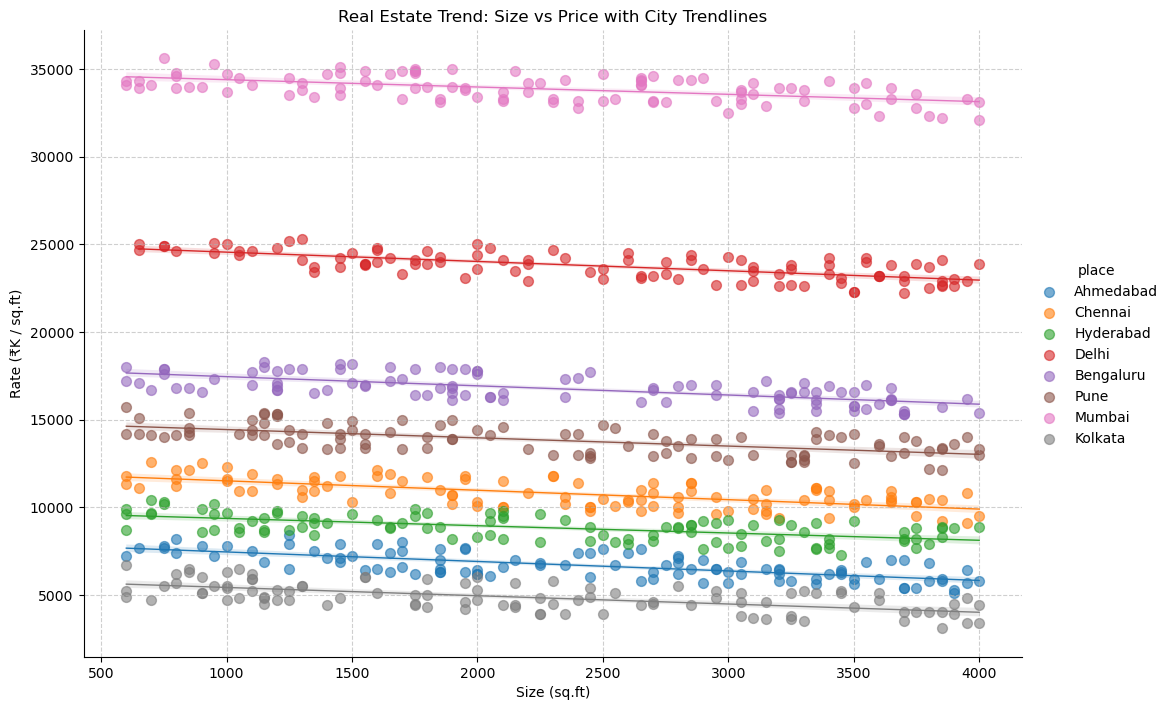

In [ ]:
ShowData(df)
inp_size = int(input("Enter size: "))
inp_place = (input("Enter place: ")).title()
RealEstatePricePredict(inp_size,inp_place)

In [6]:
dataset = [{'place': 'Ahmedabad', 'size': '1600 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Chennai', 'size': '2850 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Chennai', 'size': '600 sq.ft', 'price': '₹11.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2900 sq.ft', 'price': '₹9.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3050 sq.ft', 'price': '₹6.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3350 sq.ft', 'price': '₹5.6K/ sq.ft'}, {'place': 'Delhi', 'size': '3050 sq.ft', 'price': '₹22.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1200 sq.ft', 'price': '₹16.9K/ sq.ft'}, {'place': 'Pune', 'size': '1050 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '3600 sq.ft', 'price': '₹32.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3400 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1500 sq.ft', 'price': '₹18.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '3850 sq.ft', 'price': '₹3.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '1000 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '4000 sq.ft', 'price': '₹32.1K/ sq.ft'}, {'place': 'Delhi', 'size': '1050 sq.ft', 'price': '₹24.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '1950 sq.ft', 'price': '₹33.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2000 sq.ft', 'price': '₹17.6K/ sq.ft'}, {'place': 'Chennai', 'size': '3100 sq.ft', 'price': '₹10.5K/ sq.ft'}, {'place': 'Chennai', 'size': '2400 sq.ft', 'price': '₹11.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1000 sq.ft', 'price': '₹25.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3150 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2150 sq.ft', 'price': '₹7.0K/ sq.ft'}, {'place': 'Delhi', 'size': '2000 sq.ft', 'price': '₹24.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3750 sq.ft', 'price': '₹5.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3200 sq.ft', 'price': '₹15.6K/ sq.ft'}, {'place': 'Delhi', 'size': '2850 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2900 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '1750 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Pune', 'size': '1300 sq.ft', 'price': '₹13.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2350 sq.ft', 'price': '₹17.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '1750 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3500 sq.ft', 'price': '₹5.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1650 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3150 sq.ft', 'price': '₹8.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '2650 sq.ft', 'price': '₹34.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '3950 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3050 sq.ft', 'price': '₹8.5K/ sq.ft'}, {'place': 'Pune', 'size': '3800 sq.ft', 'price': '₹12.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1900 sq.ft', 'price': '₹16.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '750 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Delhi', 'size': '3700 sq.ft', 'price': '₹22.9K/ sq.ft'}, {'place': 'Delhi', 'size': '800 sq.ft', 'price': '₹24.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1100 sq.ft', 'price': '₹17.7K/ sq.ft'}, {'place': 'Pune', 'size': '2700 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '4000 sq.ft', 'price': '₹3.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1300 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Chennai', 'size': '2300 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Pune', 'size': '3850 sq.ft', 'price': '₹13.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1550 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '1950 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1150 sq.ft', 'price': '₹4.9K/ sq.ft'}, {'place': 'Chennai', 'size': '1700 sq.ft', 'price': '₹11.5K/ sq.ft'}, {'place': 'Pune', 'size': '4000 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Pune', 'size': '600 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1200 sq.ft', 'price': '₹17.8K/ sq.ft'}, {'place': 'Mumbai', 'size': '1700 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3500 sq.ft', 'price': '₹15.5K/ sq.ft'}, {'place': 'Delhi', 'size': '3000 sq.ft', 'price': '₹24.3K/ sq.ft'}, {'place': 'Chennai', 'size': '2100 sq.ft', 'price': '₹11.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1450 sq.ft', 'price': '₹6.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '2300 sq.ft', 'price': '₹4.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '650 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Pune', 'size': '1400 sq.ft', 'price': '₹14.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3500 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Chennai', 'size': '2000 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1350 sq.ft', 'price': '₹8.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '3000 sq.ft', 'price': '₹32.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '2400 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '2650 sq.ft', 'price': '₹34.1K/ sq.ft'}, {'place': 'Chennai', 'size': '3400 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1700 sq.ft', 'price': '₹23.3K/ sq.ft'}, {'place': 'Delhi', 'size': '1850 sq.ft', 'price': '₹24.0K/ sq.ft'}, {'place': 'Pune', 'size': '3900 sq.ft', 'price': '₹13.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '1800 sq.ft', 'price': '₹5.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2650 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '2550 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '2150 sq.ft', 'price': '₹4.3K/ sq.ft'}, {'place': 'Chennai', 'size': '1350 sq.ft', 'price': '₹11.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '3500 sq.ft', 'price': '₹32.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '2250 sq.ft', 'price': '₹3.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2650 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1700 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '1850 sq.ft', 'price': '₹33.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2850 sq.ft', 'price': '₹9.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3100 sq.ft', 'price': '₹3.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '3050 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2950 sq.ft', 'price': '₹8.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3600 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Pune', 'size': '1100 sq.ft', 'price': '₹14.4K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3200 sq.ft', 'price': '₹9.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2850 sq.ft', 'price': '₹9.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3250 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Chennai', 'size': '1300 sq.ft', 'price': '₹11.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1750 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3200 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3000 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1850 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2200 sq.ft', 'price': '₹34.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1250 sq.ft', 'price': '₹34.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '1150 sq.ft', 'price': '₹4.5K/ sq.ft'}, {'place': 'Pune', 'size': '3400 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3700 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '1000 sq.ft', 'price': '₹34.7K/ sq.ft'}, {'place': 'Delhi', 'size': '2150 sq.ft', 'price': '₹23.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2800 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '3900 sq.ft', 'price': '₹3.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2950 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Pune', 'size': '850 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3850 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2800 sq.ft', 'price': '₹7.2K/ sq.ft'}, {'place': 'Delhi', 'size': '2500 sq.ft', 'price': '₹23.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2800 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3650 sq.ft', 'price': '₹7.0K/ sq.ft'}, {'place': 'Pune', 'size': '3100 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3850 sq.ft', 'price': '₹4.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3050 sq.ft', 'price': '₹3.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1850 sq.ft', 'price': '₹18.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1200 sq.ft', 'price': '₹16.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1300 sq.ft', 'price': '₹9.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '3600 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Delhi', 'size': '2200 sq.ft', 'price': '₹22.9K/ sq.ft'}, {'place': 'Chennai', 'size': '1100 sq.ft', 'price': '₹11.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3100 sq.ft', 'price': '₹9.0K/ sq.ft'}, {'place': 'Pune', 'size': '850 sq.ft', 'price': '₹14.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2000 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Chennai', 'size': '3650 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1350 sq.ft', 'price': '₹16.5K/ sq.ft'}, {'place': 'Delhi', 'size': '2600 sq.ft', 'price': '₹24.5K/ sq.ft'}, {'place': 'Delhi', 'size': '2200 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '750 sq.ft', 'price': '₹17.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '2200 sq.ft', 'price': '₹33.7K/ sq.ft'}, {'place': 'Chennai', 'size': '2100 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2600 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3750 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3150 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1200 sq.ft', 'price': '₹16.7K/ sq.ft'}, {'place': 'Delhi', 'size': '3850 sq.ft', 'price': '₹22.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '3200 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Pune', 'size': '2800 sq.ft', 'price': '₹13.5K/ sq.ft'}, {'place': 'Pune', 'size': '2950 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '2700 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1900 sq.ft', 'price': '₹35.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2100 sq.ft', 'price': '₹6.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1100 sq.ft', 'price': '₹9.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '2250 sq.ft', 'price': '₹34.2K/ sq.ft'}, {'place': 'Pune', 'size': '2950 sq.ft', 'price': '₹12.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1100 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Pune', 'size': '1800 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Delhi', 'size': '2450 sq.ft', 'price': '₹23.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1150 sq.ft', 'price': '₹18.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2000 sq.ft', 'price': '₹10.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '1350 sq.ft', 'price': '₹33.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3650 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '2000 sq.ft', 'price': '₹5.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '4000 sq.ft', 'price': '₹15.4K/ sq.ft'}, {'place': 'Pune', 'size': '2050 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3750 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '2650 sq.ft', 'price': '₹34.5K/ sq.ft'}, {'place': 'Delhi', 'size': '3950 sq.ft', 'price': '₹22.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '1850 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2700 sq.ft', 'price': '₹8.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '2400 sq.ft', 'price': '₹32.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2650 sq.ft', 'price': '₹16.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2500 sq.ft', 'price': '₹10.5K/ sq.ft'}, {'place': 'Delhi', 'size': '2200 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '600 sq.ft', 'price': '₹8.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3350 sq.ft', 'price': '₹16.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1850 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3700 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1850 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Pune', 'size': '1550 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Delhi', 'size': '1300 sq.ft', 'price': '₹25.3K/ sq.ft'}, {'place': 'Delhi', 'size': '3900 sq.ft', 'price': '₹22.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3800 sq.ft', 'price': '₹6.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1350 sq.ft', 'price': '₹7.5K/ sq.ft'}, {'place': 'Delhi', 'size': '3600 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '850 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Pune', 'size': '600 sq.ft', 'price': '₹15.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3300 sq.ft', 'price': '₹17.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3950 sq.ft', 'price': '₹16.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3700 sq.ft', 'price': '₹22.2K/ sq.ft'}, {'place': 'Chennai', 'size': '3350 sq.ft', 'price': '₹11.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1050 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3450 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '1600 sq.ft', 'price': '₹34.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '2450 sq.ft', 'price': '₹5.4K/ sq.ft'}, {'place': 'Pune', 'size': '3350 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Chennai', 'size': '2600 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Chennai', 'size': '2300 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '3500 sq.ft', 'price': '₹4.3K/ sq.ft'}, {'place': 'Chennai', 'size': '1650 sq.ft', 'price': '₹10.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '900 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Delhi', 'size': '3750 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Chennai', 'size': '2850 sq.ft', 'price': '₹11.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '3750 sq.ft', 'price': '₹33.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1600 sq.ft', 'price': '₹9.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '700 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1250 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Delhi', 'size': '3700 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Pune', 'size': '1300 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1450 sq.ft', 'price': '₹34.8K/ sq.ft'}, {'place': 'Delhi', 'size': '750 sq.ft', 'price': '₹24.9K/ sq.ft'}, {'place': 'Chennai', 'size': '3000 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Pune', 'size': '1250 sq.ft', 'price': '₹13.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '3150 sq.ft', 'price': '₹3.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '750 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3400 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '3050 sq.ft', 'price': '₹33.7K/ sq.ft'}, {'place': 'Delhi', 'size': '1750 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Delhi', 'size': '3450 sq.ft', 'price': '₹23.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1150 sq.ft', 'price': '₹9.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '2950 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Pune', 'size': '2750 sq.ft', 'price': '₹13.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2000 sq.ft', 'price': '₹17.8K/ sq.ft'}, {'place': 'Pune', 'size': '2450 sq.ft', 'price': '₹12.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '2000 sq.ft', 'price': '₹6.0K/ sq.ft'}, {'place': 'Pune', 'size': '2700 sq.ft', 'price': '₹12.9K/ sq.ft'}, {'place': 'Delhi', 'size': '1350 sq.ft', 'price': '₹23.4K/ sq.ft'}, {'place': 'Pune', 'size': '3450 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Pune', 'size': '3700 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Pune', 'size': '1150 sq.ft', 'price': '₹15.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2950 sq.ft', 'price': '₹17.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '800 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '750 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Pune', 'size': '850 sq.ft', 'price': '₹15.4K/ sq.ft'}, {'place': 'Pune', 'size': '3300 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '3550 sq.ft', 'price': '₹33.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3700 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Pune', 'size': '800 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Chennai', 'size': '3950 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Chennai', 'size': '2700 sq.ft', 'price': '₹11.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '800 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1450 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Chennai', 'size': '3150 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '2700 sq.ft', 'price': '₹33.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2350 sq.ft', 'price': '₹16.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3150 sq.ft', 'price': '₹11.0K/ sq.ft'}, {'place': 'Delhi', 'size': '3800 sq.ft', 'price': '₹22.5K/ sq.ft'}, {'place': 'Delhi', 'size': '2750 sq.ft', 'price': '₹24.0K/ sq.ft'}, {'place': 'Chennai', 'size': '3800 sq.ft', 'price': '₹10.5K/ sq.ft'}, {'place': 'Chennai', 'size': '1100 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3250 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Delhi', 'size': '3100 sq.ft', 'price': '₹22.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3250 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2000 sq.ft', 'price': '₹17.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3850 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '950 sq.ft', 'price': '₹17.3K/ sq.ft'}, {'place': 'Chennai', 'size': '1200 sq.ft', 'price': '₹11.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1850 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Chennai', 'size': '2450 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2450 sq.ft', 'price': '₹17.7K/ sq.ft'}, {'place': 'Chennai', 'size': '4000 sq.ft', 'price': '₹9.5K/ sq.ft'}, {'place': 'Pune', 'size': '750 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2000 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Pune', 'size': '1250 sq.ft', 'price': '₹14.4K/ sq.ft'}, {'place': 'Delhi', 'size': '3250 sq.ft', 'price': '₹23.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '2700 sq.ft', 'price': '₹4.5K/ sq.ft'}, {'place': 'Pune', 'size': '1550 sq.ft', 'price': '₹13.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1650 sq.ft', 'price': '₹17.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '1200 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '3450 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2100 sq.ft', 'price': '₹16.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1950 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Pune', 'size': '3300 sq.ft', 'price': '₹12.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1300 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1750 sq.ft', 'price': '₹5.0K/ sq.ft'}, {'place': 'Chennai', 'size': '3650 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Delhi', 'size': '3900 sq.ft', 'price': '₹23.0K/ sq.ft'}, {'place': 'Pune', 'size': '1200 sq.ft', 'price': '₹13.6K/ sq.ft'}, {'place': 'Pune', 'size': '3600 sq.ft', 'price': '₹13.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '1550 sq.ft', 'price': '₹34.9K/ sq.ft'}, {'place': 'Chennai', 'size': '1350 sq.ft', 'price': '₹11.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '2950 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3450 sq.ft', 'price': '₹6.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '3750 sq.ft', 'price': '₹32.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2750 sq.ft', 'price': '₹6.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2750 sq.ft', 'price': '₹16.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2700 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Pune', 'size': '1900 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Chennai', 'size': '1600 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Delhi', 'size': '2750 sq.ft', 'price': '₹23.3K/ sq.ft'}, {'place': 'Chennai', 'size': '1600 sq.ft', 'price': '₹12.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '3650 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '600 sq.ft', 'price': '₹6.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '900 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '2500 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1900 sq.ft', 'price': '₹16.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '600 sq.ft', 'price': '₹9.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1450 sq.ft', 'price': '₹7.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3000 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Pune', 'size': '2500 sq.ft', 'price': '₹14.7K/ sq.ft'}, {'place': 'Chennai', 'size': '1350 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Chennai', 'size': '1900 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Delhi', 'size': '950 sq.ft', 'price': '₹25.1K/ sq.ft'}, {'place': 'Chennai', 'size': '2950 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Chennai', 'size': '1000 sq.ft', 'price': '₹12.3K/ sq.ft'}, {'place': 'Chennai', 'size': '2850 sq.ft', 'price': '₹11.4K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2100 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '3100 sq.ft', 'price': '₹34.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3400 sq.ft', 'price': '₹23.3K/ sq.ft'}, {'place': 'Chennai', 'size': '1800 sq.ft', 'price': '₹11.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2450 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3550 sq.ft', 'price': '₹15.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2500 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1850 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Pune', 'size': '1450 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3850 sq.ft', 'price': '₹22.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '950 sq.ft', 'price': '₹7.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3200 sq.ft', 'price': '₹16.4K/ sq.ft'}, {'place': 'Pune', 'size': '2750 sq.ft', 'price': '₹13.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '4000 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1450 sq.ft', 'price': '₹18.2K/ sq.ft'}, {'place': 'Chennai', 'size': '1500 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '2700 sq.ft', 'price': '₹4.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '2650 sq.ft', 'price': '₹34.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3400 sq.ft', 'price': '₹9.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1200 sq.ft', 'price': '₹24.8K/ sq.ft'}, {'place': 'Chennai', 'size': '3500 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3200 sq.ft', 'price': '₹6.4K/ sq.ft'}, {'place': 'Delhi', 'size': '2350 sq.ft', 'price': '₹24.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3350 sq.ft', 'price': '₹15.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1200 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3700 sq.ft', 'price': '₹5.4K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3350 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2950 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1650 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Pune', 'size': '2400 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '1450 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '800 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Chennai', 'size': '2950 sq.ft', 'price': '₹10.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '600 sq.ft', 'price': '₹7.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1650 sq.ft', 'price': '₹34.7K/ sq.ft'}, {'place': 'Pune', 'size': '1650 sq.ft', 'price': '₹14.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '3150 sq.ft', 'price': '₹4.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '600 sq.ft', 'price': '₹34.3K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2900 sq.ft', 'price': '₹7.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '1100 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2600 sq.ft', 'price': '₹7.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2350 sq.ft', 'price': '₹6.7K/ sq.ft'}, {'place': 'Delhi', 'size': '650 sq.ft', 'price': '₹24.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3050 sq.ft', 'price': '₹7.8K/ sq.ft'}, {'place': 'Pune', 'size': '3500 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Pune', 'size': '3500 sq.ft', 'price': '₹12.5K/ sq.ft'}, {'place': 'Delhi', 'size': '3550 sq.ft', 'price': '₹24.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1250 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '3950 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '2150 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Chennai', 'size': '2350 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Pune', 'size': '4000 sq.ft', 'price': '₹13.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3550 sq.ft', 'price': '₹17.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2100 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3950 sq.ft', 'price': '₹6.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '1450 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Delhi', 'size': '3450 sq.ft', 'price': '₹22.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '600 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Delhi', 'size': '1600 sq.ft', 'price': '₹24.0K/ sq.ft'}, {'place': 'Delhi', 'size': '3100 sq.ft', 'price': '₹23.7K/ sq.ft'}, {'place': 'Chennai', 'size': '2650 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Pune', 'size': '3850 sq.ft', 'price': '₹13.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2700 sq.ft', 'price': '₹16.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1500 sq.ft', 'price': '₹17.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1000 sq.ft', 'price': '₹7.8K/ sq.ft'}, {'place': 'Chennai', 'size': '700 sq.ft', 'price': '₹12.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '1950 sq.ft', 'price': '₹4.6K/ sq.ft'}, {'place': 'Pune', 'size': '1700 sq.ft', 'price': '₹15.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '1800 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '750 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2550 sq.ft', 'price': '₹6.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3500 sq.ft', 'price': '₹15.8K/ sq.ft'}, {'place': 'Delhi', 'size': '3300 sq.ft', 'price': '₹22.6K/ sq.ft'}, {'place': 'Chennai', 'size': '2700 sq.ft', 'price': '₹10.1K/ sq.ft'}, {'place': 'Chennai', 'size': '2800 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Chennai', 'size': '3550 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Pune', 'size': '1500 sq.ft', 'price': '₹14.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '1100 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2250 sq.ft', 'price': '₹6.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2700 sq.ft', 'price': '₹8.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2800 sq.ft', 'price': '₹6.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '3750 sq.ft', 'price': '₹4.0K/ sq.ft'}, {'place': 'Delhi', 'size': '950 sq.ft', 'price': '₹24.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3850 sq.ft', 'price': '₹8.3K/ sq.ft'}, {'place': 'Pune', 'size': '2550 sq.ft', 'price': '₹14.5K/ sq.ft'}, {'place': 'Delhi', 'size': '2650 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2700 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '1000 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Delhi', 'size': '2900 sq.ft', 'price': '₹23.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1150 sq.ft', 'price': '₹8.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '800 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1450 sq.ft', 'price': '₹35.1K/ sq.ft'}, {'place': 'Delhi', 'size': '3400 sq.ft', 'price': '₹23.8K/ sq.ft'}, {'place': 'Delhi', 'size': '3650 sq.ft', 'price': '₹23.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1700 sq.ft', 'price': '₹6.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '3050 sq.ft', 'price': '₹33.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1100 sq.ft', 'price': '₹17.0K/ sq.ft'}, {'place': 'Pune', 'size': '1900 sq.ft', 'price': '₹15.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1650 sq.ft', 'price': '₹7.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '2550 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Pune', 'size': '1200 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '2850 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '1050 sq.ft', 'price': '₹34.5K/ sq.ft'}, {'place': 'Pune', 'size': '2100 sq.ft', 'price': '₹14.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '1000 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3600 sq.ft', 'price': '₹15.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1550 sq.ft', 'price': '₹6.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '800 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1950 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2650 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Pune', 'size': '2200 sq.ft', 'price': '₹13.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2700 sq.ft', 'price': '₹34.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '3400 sq.ft', 'price': '₹34.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '3800 sq.ft', 'price': '₹32.3K/ sq.ft'}, {'place': 'Chennai', 'size': '800 sq.ft', 'price': '₹11.2K/ sq.ft'}, {'place': 'Chennai', 'size': '2700 sq.ft', 'price': '₹10.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3000 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2950 sq.ft', 'price': '₹16.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1850 sq.ft', 'price': '₹7.0K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2450 sq.ft', 'price': '₹7.4K/ sq.ft'}, {'place': 'Chennai', 'size': '1950 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Delhi', 'size': '1500 sq.ft', 'price': '₹24.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '3250 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2750 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '950 sq.ft', 'price': '₹8.7K/ sq.ft'}, {'place': 'Delhi', 'size': '1450 sq.ft', 'price': '₹24.2K/ sq.ft'}, {'place': 'Chennai', 'size': '3100 sq.ft', 'price': '₹9.9K/ sq.ft'}, {'place': 'Delhi', 'size': '1300 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3400 sq.ft', 'price': '₹16.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '1700 sq.ft', 'price': '₹34.9K/ sq.ft'}, {'place': 'Delhi', 'size': '2650 sq.ft', 'price': '₹23.1K/ sq.ft'}, {'place': 'Pune', 'size': '3300 sq.ft', 'price': '₹12.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3650 sq.ft', 'price': '₹16.1K/ sq.ft'}, {'place': 'Chennai', 'size': '3300 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3100 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '3300 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '2450 sq.ft', 'price': '₹4.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1150 sq.ft', 'price': '₹6.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '1750 sq.ft', 'price': '₹34.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1700 sq.ft', 'price': '₹17.3K/ sq.ft'}, {'place': 'Pune', 'size': '3250 sq.ft', 'price': '₹12.6K/ sq.ft'}, {'place': 'Pune', 'size': '2850 sq.ft', 'price': '₹12.8K/ sq.ft'}, {'place': 'Delhi', 'size': '2100 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '650 sq.ft', 'price': '₹34.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2500 sq.ft', 'price': '₹34.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1600 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '600 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Chennai', 'size': '3850 sq.ft', 'price': '₹9.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '600 sq.ft', 'price': '₹17.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '1950 sq.ft', 'price': '₹4.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2050 sq.ft', 'price': '₹16.3K/ sq.ft'}, {'place': 'Delhi', 'size': '3200 sq.ft', 'price': '₹22.6K/ sq.ft'}, {'place': 'Delhi', 'size': '3850 sq.ft', 'price': '₹22.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3300 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1800 sq.ft', 'price': '₹16.4K/ sq.ft'}, {'place': 'Pune', 'size': '2000 sq.ft', 'price': '₹14.4K/ sq.ft'}, {'place': 'Chennai', 'size': '1000 sq.ft', 'price': '₹11.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2850 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '3250 sq.ft', 'price': '₹3.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1900 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3100 sq.ft', 'price': '₹23.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '3550 sq.ft', 'price': '₹34.2K/ sq.ft'}, {'place': 'Pune', 'size': '850 sq.ft', 'price': '₹14.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1550 sq.ft', 'price': '₹17.0K/ sq.ft'}, {'place': 'Pune', 'size': '650 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '3050 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '1750 sq.ft', 'price': '₹4.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '3250 sq.ft', 'price': '₹3.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2800 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1400 sq.ft', 'price': '₹7.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '900 sq.ft', 'price': '₹6.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1750 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3850 sq.ft', 'price': '₹15.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3400 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Delhi', 'size': '1050 sq.ft', 'price': '₹24.4K/ sq.ft'}, {'place': 'Pune', 'size': '1150 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '3100 sq.ft', 'price': '₹33.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '3600 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2050 sq.ft', 'price': '₹8.4K/ sq.ft'}, {'place': 'Delhi', 'size': '2700 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '3150 sq.ft', 'price': '₹32.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2400 sq.ft', 'price': '₹7.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1800 sq.ft', 'price': '₹24.6K/ sq.ft'}, {'place': 'Delhi', 'size': '3850 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3400 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '3500 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Delhi', 'size': '2050 sq.ft', 'price': '₹24.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '1050 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3700 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1400 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '700 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Chennai', 'size': '1850 sq.ft', 'price': '₹11.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '2950 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3450 sq.ft', 'price': '₹7.3K/ sq.ft'}, {'place': 'Pune', 'size': '1150 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3750 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Chennai', 'size': '850 sq.ft', 'price': '₹12.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2800 sq.ft', 'price': '₹16.9K/ sq.ft'}, {'place': 'Delhi', 'size': '1600 sq.ft', 'price': '₹24.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '1100 sq.ft', 'price': '₹34.1K/ sq.ft'}, {'place': 'Pune', 'size': '3000 sq.ft', 'price': '₹12.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '650 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2400 sq.ft', 'price': '₹17.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '2150 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Chennai', 'size': '3650 sq.ft', 'price': '₹10.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2250 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '1250 sq.ft', 'price': '₹33.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1950 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3200 sq.ft', 'price': '₹15.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '3650 sq.ft', 'price': '₹33.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '950 sq.ft', 'price': '₹35.3K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3700 sq.ft', 'price': '₹7.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '900 sq.ft', 'price': '₹9.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '750 sq.ft', 'price': '₹7.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2050 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1050 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Pune', 'size': '2300 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Delhi', 'size': '3600 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3250 sq.ft', 'price': '₹16.5K/ sq.ft'}, {'place': 'Pune', 'size': '1400 sq.ft', 'price': '₹13.3K/ sq.ft'}, {'place': 'Pune', 'size': '1500 sq.ft', 'price': '₹14.9K/ sq.ft'}, {'place': 'Pune', 'size': '2850 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Pune', 'size': '2600 sq.ft', 'price': '₹13.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '800 sq.ft', 'price': '₹34.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1750 sq.ft', 'price': '₹9.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2700 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1800 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1550 sq.ft', 'price': '₹6.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '2100 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '1750 sq.ft', 'price': '₹34.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2800 sq.ft', 'price': '₹7.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '2100 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Chennai', 'size': '1950 sq.ft', 'price': '₹11.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2900 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2050 sq.ft', 'price': '₹6.1K/ sq.ft'}, {'place': 'Pune', 'size': '3600 sq.ft', 'price': '₹13.5K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2250 sq.ft', 'price': '₹6.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1450 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Pune', 'size': '1900 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3650 sq.ft', 'price': '₹16.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1300 sq.ft', 'price': '₹34.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3500 sq.ft', 'price': '₹9.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3050 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Delhi', 'size': '750 sq.ft', 'price': '₹24.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3850 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '900 sq.ft', 'price': '₹7.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3550 sq.ft', 'price': '₹6.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '3300 sq.ft', 'price': '₹33.8K/ sq.ft'}, {'place': 'Pune', 'size': '3700 sq.ft', 'price': '₹13.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3500 sq.ft', 'price': '₹15.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3400 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '2300 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Pune', 'size': '3300 sq.ft', 'price': '₹12.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '2000 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '3300 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Delhi', 'size': '650 sq.ft', 'price': '₹25.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3300 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Chennai', 'size': '2100 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3300 sq.ft', 'price': '₹3.5K/ sq.ft'}, {'place': 'Chennai', 'size': '1050 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1900 sq.ft', 'price': '₹16.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '2300 sq.ft', 'price': '₹33.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '1750 sq.ft', 'price': '₹35.0K/ sq.ft'}, {'place': 'Delhi', 'size': '1650 sq.ft', 'price': '₹24.2K/ sq.ft'}, {'place': 'Delhi', 'size': '2950 sq.ft', 'price': '₹22.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3200 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Chennai', 'size': '1300 sq.ft', 'price': '₹10.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3450 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3000 sq.ft', 'price': '₹9.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '1000 sq.ft', 'price': '₹33.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3900 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '1300 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2050 sq.ft', 'price': '₹16.3K/ sq.ft'}, {'place': 'Delhi', 'size': '1850 sq.ft', 'price': '₹24.3K/ sq.ft'}, {'place': 'Pune', 'size': '650 sq.ft', 'price': '₹15.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '3450 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3450 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Delhi', 'size': '2300 sq.ft', 'price': '₹24.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '1300 sq.ft', 'price': '₹33.8K/ sq.ft'}, {'place': 'Chennai', 'size': '1000 sq.ft', 'price': '₹11.6K/ sq.ft'}, {'place': 'Pune', 'size': '3350 sq.ft', 'price': '₹14.3K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1900 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Chennai', 'size': '3500 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3200 sq.ft', 'price': '₹16.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3900 sq.ft', 'price': '₹5.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2750 sq.ft', 'price': '₹33.1K/ sq.ft'}, {'place': 'Delhi', 'size': '3250 sq.ft', 'price': '₹22.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3050 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '950 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Pune', 'size': '1850 sq.ft', 'price': '₹14.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3350 sq.ft', 'price': '₹16.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '750 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Pune', 'size': '2350 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Chennai', 'size': '800 sq.ft', 'price': '₹12.1K/ sq.ft'}, {'place': 'Delhi', 'size': '3250 sq.ft', 'price': '₹23.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2500 sq.ft', 'price': '₹8.4K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2550 sq.ft', 'price': '₹8.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '1250 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2600 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3650 sq.ft', 'price': '₹16.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '2850 sq.ft', 'price': '₹34.4K/ sq.ft'}, {'place': 'Chennai', 'size': '600 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Chennai', 'size': '1200 sq.ft', 'price': '₹11.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3150 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '900 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Chennai', 'size': '3950 sq.ft', 'price': '₹10.8K/ sq.ft'}, {'place': 'Chennai', 'size': '3350 sq.ft', 'price': '₹11.0K/ sq.ft'}, {'place': 'Pune', 'size': '2450 sq.ft', 'price': '₹12.9K/ sq.ft'}, {'place': 'Pune', 'size': '1200 sq.ft', 'price': '₹15.3K/ sq.ft'}, {'place': 'Kolkata', 'size': '2250 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3350 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2000 sq.ft', 'price': '₹8.3K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3800 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Pune', 'size': '1100 sq.ft', 'price': '₹15.0K/ sq.ft'}, {'place': 'Delhi', 'size': '3200 sq.ft', 'price': '₹23.3K/ sq.ft'}, {'place': 'Pune', 'size': '3050 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3700 sq.ft', 'price': '₹3.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1000 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3200 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Delhi', 'size': '1350 sq.ft', 'price': '₹23.7K/ sq.ft'}, {'place': 'Pune', 'size': '3750 sq.ft', 'price': '₹13.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '1000 sq.ft', 'price': '₹5.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1800 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1800 sq.ft', 'price': '₹4.3K/ sq.ft'}, {'place': 'Pune', 'size': '1800 sq.ft', 'price': '₹13.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '2100 sq.ft', 'price': '₹33.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '750 sq.ft', 'price': '₹10.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1650 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Chennai', 'size': '2350 sq.ft', 'price': '₹10.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '2900 sq.ft', 'price': '₹34.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '2500 sq.ft', 'price': '₹3.9K/ sq.ft'}, {'place': 'Delhi', 'size': '3400 sq.ft', 'price': '₹24.2K/ sq.ft'}, {'place': 'Pune', 'size': '2450 sq.ft', 'price': '₹13.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3700 sq.ft', 'price': '₹8.2K/ sq.ft'}, {'place': 'Delhi', 'size': '3550 sq.ft', 'price': '₹24.0K/ sq.ft'}, {'place': 'Pune', 'size': '3250 sq.ft', 'price': '₹13.0K/ sq.ft'}, {'place': 'Chennai', 'size': '3750 sq.ft', 'price': '₹9.5K/ sq.ft'}, {'place': 'Delhi', 'size': '1450 sq.ft', 'price': '₹23.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '600 sq.ft', 'price': '₹18.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3700 sq.ft', 'price': '₹4.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1750 sq.ft', 'price': '₹9.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3700 sq.ft', 'price': '₹5.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '1400 sq.ft', 'price': '₹34.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '1250 sq.ft', 'price': '₹5.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '1450 sq.ft', 'price': '₹33.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '950 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2050 sq.ft', 'price': '₹9.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2100 sq.ft', 'price': '₹9.4K/ sq.ft'}, {'place': 'Chennai', 'size': '2550 sq.ft', 'price': '₹10.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '600 sq.ft', 'price': '₹4.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '1300 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Pune', 'size': '3250 sq.ft', 'price': '₹12.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3500 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '700 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '2000 sq.ft', 'price': '₹33.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1550 sq.ft', 'price': '₹16.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '3050 sq.ft', 'price': '₹4.6K/ sq.ft'}, {'place': 'Hyderabad', 'size': '4000 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2450 sq.ft', 'price': '₹8.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3200 sq.ft', 'price': '₹16.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '1600 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '600 sq.ft', 'price': '₹34.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1200 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1350 sq.ft', 'price': '₹9.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '3350 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '3050 sq.ft', 'price': '₹33.0K/ sq.ft'}, {'place': 'Pune', 'size': '3650 sq.ft', 'price': '₹12.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1950 sq.ft', 'price': '₹16.4K/ sq.ft'}, {'place': 'Delhi', 'size': '3500 sq.ft', 'price': '₹22.3K/ sq.ft'}, {'place': 'Delhi', 'size': '3500 sq.ft', 'price': '₹22.3K/ sq.ft'}, {'place': 'Chennai', 'size': '3650 sq.ft', 'price': '₹10.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1250 sq.ft', 'price': '₹8.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3350 sq.ft', 'price': '₹7.6K/ sq.ft'}, {'place': 'Pune', 'size': '2400 sq.ft', 'price': '₹14.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '700 sq.ft', 'price': '₹34.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3200 sq.ft', 'price': '₹7.5K/ sq.ft'}, {'place': 'Chennai', 'size': '3850 sq.ft', 'price': '₹10.4K/ sq.ft'}, {'place': 'Bengaluru', 'size': '650 sq.ft', 'price': '₹17.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1150 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3700 sq.ft', 'price': '₹15.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3350 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1400 sq.ft', 'price': '₹16.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '700 sq.ft', 'price': '₹16.7K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1250 sq.ft', 'price': '₹8.4K/ sq.ft'}, {'place': 'Mumbai', 'size': '2350 sq.ft', 'price': '₹34.4K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1350 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '950 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Kolkata', 'size': '1550 sq.ft', 'price': '₹6.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '1750 sq.ft', 'price': '₹34.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2800 sq.ft', 'price': '₹6.2K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1500 sq.ft', 'price': '₹7.2K/ sq.ft'}, {'place': 'Chennai', 'size': '3350 sq.ft', 'price': '₹11.1K/ sq.ft'}, {'place': 'Chennai', 'size': '1450 sq.ft', 'price': '₹11.8K/ sq.ft'}, {'place': 'Delhi', 'size': '3600 sq.ft', 'price': '₹23.2K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1200 sq.ft', 'price': '₹17.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1900 sq.ft', 'price': '₹17.9K/ sq.ft'}, {'place': 'Pune', 'size': '700 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '1050 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Delhi', 'size': '1250 sq.ft', 'price': '₹25.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '700 sq.ft', 'price': '₹4.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3150 sq.ft', 'price': '₹17.2K/ sq.ft'}, {'place': 'Mumbai', 'size': '850 sq.ft', 'price': '₹34.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '2150 sq.ft', 'price': '₹34.9K/ sq.ft'}, {'place': 'Pune', 'size': '3800 sq.ft', 'price': '₹13.2K/ sq.ft'}, {'place': 'Pune', 'size': '1450 sq.ft', 'price': '₹13.9K/ sq.ft'}, {'place': 'Kolkata', 'size': '2350 sq.ft', 'price': '₹3.9K/ sq.ft'}, {'place': 'Delhi', 'size': '4000 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3950 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Delhi', 'size': '2000 sq.ft', 'price': '₹25.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '2250 sq.ft', 'price': '₹3.9K/ sq.ft'}, {'place': 'Pune', 'size': '3850 sq.ft', 'price': '₹12.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1700 sq.ft', 'price': '₹8.0K/ sq.ft'}, {'place': 'Kolkata', 'size': '3900 sq.ft', 'price': '₹4.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '800 sq.ft', 'price': '₹34.6K/ sq.ft'}, {'place': 'Chennai', 'size': '3750 sq.ft', 'price': '₹10.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2300 sq.ft', 'price': '₹33.3K/ sq.ft'}, {'place': 'Mumbai', 'size': '2800 sq.ft', 'price': '₹34.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '2800 sq.ft', 'price': '₹5.5K/ sq.ft'}, {'place': 'Chennai', 'size': '650 sq.ft', 'price': '₹11.1K/ sq.ft'}, {'place': 'Bengaluru', 'size': '850 sq.ft', 'price': '₹16.8K/ sq.ft'}, {'place': 'Chennai', 'size': '1650 sq.ft', 'price': '₹11.9K/ sq.ft'}, {'place': 'Mumbai', 'size': '2400 sq.ft', 'price': '₹33.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3700 sq.ft', 'price': '₹8.1K/ sq.ft'}, {'place': 'Mumbai', 'size': '4000 sq.ft', 'price': '₹33.1K/ sq.ft'}, {'place': 'Delhi', 'size': '1600 sq.ft', 'price': '₹24.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '1150 sq.ft', 'price': '₹4.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2450 sq.ft', 'price': '₹6.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2800 sq.ft', 'price': '₹10.6K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2850 sq.ft', 'price': '₹17.0K/ sq.ft'}, {'place': 'Pune', 'size': '1450 sq.ft', 'price': '₹13.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '900 sq.ft', 'price': '₹5.1K/ sq.ft'}, {'place': 'Delhi', 'size': '2000 sq.ft', 'price': '₹23.6K/ sq.ft'}, {'place': 'Mumbai', 'size': '750 sq.ft', 'price': '₹35.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '3200 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Delhi', 'size': '1550 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Delhi', 'size': '1750 sq.ft', 'price': '₹23.9K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1700 sq.ft', 'price': '₹7.5K/ sq.ft'}, {'place': 'Bengaluru', 'size': '2100 sq.ft', 'price': '₹16.1K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '4000 sq.ft', 'price': '₹5.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '1200 sq.ft', 'price': '₹5.3K/ sq.ft'}, {'place': 'Chennai', 'size': '2450 sq.ft', 'price': '₹9.8K/ sq.ft'}, {'place': 'Chennai', 'size': '900 sq.ft', 'price': '₹12.5K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3350 sq.ft', 'price': '₹15.9K/ sq.ft'}, {'place': 'Pune', 'size': '1200 sq.ft', 'price': '₹15.2K/ sq.ft'}, {'place': 'Kolkata', 'size': '1950 sq.ft', 'price': '₹5.7K/ sq.ft'}, {'place': 'Delhi', 'size': '1100 sq.ft', 'price': '₹24.6K/ sq.ft'}, {'place': 'Chennai', 'size': '1900 sq.ft', 'price': '₹10.7K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3750 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Kolkata', 'size': '3800 sq.ft', 'price': '₹4.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '1900 sq.ft', 'price': '₹34.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3900 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2250 sq.ft', 'price': '₹8.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '3850 sq.ft', 'price': '₹32.2K/ sq.ft'}, {'place': 'Chennai', 'size': '1900 sq.ft', 'price': '₹10.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '2100 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Delhi', 'size': '2600 sq.ft', 'price': '₹24.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '850 sq.ft', 'price': '₹6.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2950 sq.ft', 'price': '₹9.1K/ sq.ft'}, {'place': 'Chennai', 'size': '2650 sq.ft', 'price': '₹11.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2350 sq.ft', 'price': '₹9.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1500 sq.ft', 'price': '₹9.6K/ sq.ft'}, {'place': 'Pune', 'size': '3950 sq.ft', 'price': '₹14.0K/ sq.ft'}, {'place': 'Chennai', 'size': '2450 sq.ft', 'price': '₹10.0K/ sq.ft'}, {'place': 'Chennai', 'size': '3200 sq.ft', 'price': '₹9.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1950 sq.ft', 'price': '₹7.7K/ sq.ft'}, {'place': 'Mumbai', 'size': '1800 sq.ft', 'price': '₹34.0K/ sq.ft'}, {'place': 'Chennai', 'size': '800 sq.ft', 'price': '₹11.6K/ sq.ft'}, {'place': 'Pune', 'size': '1550 sq.ft', 'price': '₹13.6K/ sq.ft'}, {'place': 'Pune', 'size': '1150 sq.ft', 'price': '₹14.8K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1100 sq.ft', 'price': '₹7.5K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1800 sq.ft', 'price': '₹9.7K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1650 sq.ft', 'price': '₹18.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '1850 sq.ft', 'price': '₹8.9K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2100 sq.ft', 'price': '₹9.5K/ sq.ft'}, {'place': 'Kolkata', 'size': '1400 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Delhi', 'size': '2500 sq.ft', 'price': '₹23.6K/ sq.ft'}, {'place': 'Chennai', 'size': '1400 sq.ft', 'price': '₹11.2K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3850 sq.ft', 'price': '₹8.8K/ sq.ft'}, {'place': 'Delhi', 'size': '1950 sq.ft', 'price': '₹23.1K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3800 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1750 sq.ft', 'price': '₹16.4K/ sq.ft'}, {'place': 'Delhi', 'size': '2800 sq.ft', 'price': '₹23.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2850 sq.ft', 'price': '₹8.6K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '2000 sq.ft', 'price': '₹6.4K/ sq.ft'}, {'place': 'Delhi', 'size': '1550 sq.ft', 'price': '₹23.8K/ sq.ft'}, {'place': 'Mumbai', 'size': '1550 sq.ft', 'price': '₹34.3K/ sq.ft'}, {'place': 'Pune', 'size': '1100 sq.ft', 'price': '₹14.1K/ sq.ft'}, {'place': 'Kolkata', 'size': '3950 sq.ft', 'price': '₹3.4K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '800 sq.ft', 'price': '₹7.4K/ sq.ft'}, {'place': 'Pune', 'size': '1700 sq.ft', 'price': '₹13.3K/ sq.ft'}, {'place': 'Hyderabad', 'size': '2600 sq.ft', 'price': '₹7.9K/ sq.ft'}, {'place': 'Bengaluru', 'size': '3100 sq.ft', 'price': '₹15.5K/ sq.ft'}, {'place': 'Delhi', 'size': '3800 sq.ft', 'price': '₹23.7K/ sq.ft'}, {'place': 'Kolkata', 'size': '1100 sq.ft', 'price': '₹5.9K/ sq.ft'}, {'place': 'Delhi', 'size': '2850 sq.ft', 'price': '₹24.4K/ sq.ft'}, {'place': 'Kolkata', 'size': '2650 sq.ft', 'price': '₹4.4K/ sq.ft'}, {'place': 'Chennai', 'size': '2200 sq.ft', 'price': '₹10.8K/ sq.ft'}, {'place': 'Bengaluru', 'size': '1150 sq.ft', 'price': '₹18.3K/ sq.ft'}, {'place': 'Ahmedabad', 'size': '1250 sq.ft', 'price': '₹6.5K/ sq.ft'}, {'place': 'Mumbai', 'size': '900 sq.ft', 'price': '₹34.0K/ sq.ft'}, {'place': 'Hyderabad', 'size': '3250 sq.ft', 'price': '₹9.0K/ sq.ft'}, {'place': 'Mumbai', 'size': '2650 sq.ft', 'price': '₹34.1K/ sq.ft'}]
